# MSCS 634 - Advanced Data Mining

## Project Deliverable 2: Regression Modeling and Performance Evaluation

**Student:** Lonnell Johnson

### Purpose

The purpose of this deliverable is to extend the Online Retail dataset analysis by applying feature engineering and regression modeling techniques. Multiple regression models will be developed and evaluated using R-squared, Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and cross-validation. The goal is to compare model performance and determine which approach generalizes best to unseen retail transaction data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("cleaned_online_retail.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (392692, 15)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceHour,DayOfWeek,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,2010,12,1,8,Wednesday,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,2010,12,1,8,Wednesday,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,2010,12,1,8,Wednesday,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,2010,12,1,8,Wednesday,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,2010,12,1,8,Wednesday,2010-12


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     392692 non-null  int64  
 1   StockCode     392692 non-null  str    
 2   Description   392692 non-null  str    
 3   Quantity      392692 non-null  int64  
 4   InvoiceDate   392692 non-null  str    
 5   UnitPrice     392692 non-null  float64
 6   CustomerID    392692 non-null  int64  
 7   Country       392692 non-null  str    
 8   IsCancelled   392692 non-null  bool   
 9   InvoiceYear   392692 non-null  int64  
 10  InvoiceMonth  392692 non-null  int64  
 11  InvoiceDay    392692 non-null  int64  
 12  InvoiceHour   392692 non-null  int64  
 13  DayOfWeek     392692 non-null  str    
 14  YearMonth     392692 non-null  str    
dtypes: bool(1), float64(1), int64(7), str(6)
memory usage: 42.3 MB


In [4]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceHour
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,3.125914,15287.843865,2010.934631,7.601871,15.044656,12.721532
std,13087.063759,180.492832,22.241836,1713.539549,0.247177,3.415015,8.652532,2.276661
min,536365.000000,1.000000,0.001000,12346.000000,2010.000000,1.000000,1.000000,6.000000
25%,549234.000000,2.000000,1.250000,13955.000000,2011.000000,5.000000,7.000000,11.000000
50%,561874.000000,6.000000,1.950000,15150.000000,2011.000000,8.000000,15.000000,13.000000
75%,572061.000000,12.000000,3.750000,16791.000000,2011.000000,11.000000,22.000000,14.000000
max,581587.000000,80995.000000,8142.750000,18287.000000,2011.000000,12.000000,31.000000,20.000000


In [5]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'IsCancelled', 'InvoiceYear', 'InvoiceMonth', 'InvoiceDay', 'InvoiceHour', 'DayOfWeek', 'YearMonth']


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
IsCancelled     0
InvoiceYear     0
InvoiceMonth    0
InvoiceDay      0
InvoiceHour     0
DayOfWeek       0
YearMonth       0
dtype: int64


## Data Preparation

The cleaned Online Retail dataset from Project Deliverable 1 was used for this phase of the project. The dataset was inspected for missing values, data types, and descriptive statistics before regression modeling. Using the cleaned dataset ensured that the regression analysis was performed on data that had already undergone preprocessing.

In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[us]


In [8]:
df["LineTotal"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "LineTotal"]].head()

,Quantity,UnitPrice,LineTotal
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [9]:
df["Month"] = df["InvoiceDate"].dt.month
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["Hour"] = df["InvoiceDate"].dt.hour

df[["InvoiceDate", "Month", "DayOfWeek", "Hour"]].head()

,InvoiceDate,Month,DayOfWeek,Hour
0,2010-12-01 08:26:00,12,2,8
1,2010-12-01 08:26:00,12,2,8
2,2010-12-01 08:26:00,12,2,8
3,2010-12-01 08:26:00,12,2,8
4,2010-12-01 08:26:00,12,2,8


## Feature Engineering

Several new features were created to improve the usefulness of the dataset for regression modeling. Revenue for each transaction line was calculated using Quantity multiplied by UnitPrice. Date information was also transformed into Month, DayOfWeek, and Hour features. The individual transaction rows were then aggregated to the invoice level so that the models could predict total invoice value using characteristics of each purchase.

In [10]:
invoice_df = df.groupby("InvoiceNo").agg(
    InvoiceTotal=("LineTotal", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    AverageUnitPrice=("UnitPrice", "mean"),
    Month=("Month", "first"),
    DayOfWeek=("DayOfWeek", "first"),
    Hour=("Hour", "first")
).reset_index()

invoice_df.head()

,InvoiceNo,InvoiceTotal,TotalQuantity,UniqueProducts,AverageUnitPrice,Month,DayOfWeek,Hour
0,536365,139.12,40,7,3.910000,12,2,8
1,536366,22.20,12,2,1.850000,12,2,8
2,536367,278.73,83,12,4.853333,12,2,8
3,536368,70.05,15,4,4.775000,12,2,8
4,536369,17.85,3,1,5.950000,12,2,8


In [11]:
invoice_df.shape

(18532, 8)

In [12]:
invoice_df.describe()

,InvoiceNo,InvoiceTotal,TotalQuantity,UniqueProducts,AverageUnitPrice,Month,DayOfWeek,Hour
count,18532.000000,18532.00000,18532.000000,18532.000000,18532.000000,18532.000000,18532.000000,18532.000000
mean,559527.062487,479.56016,278.005720,20.928178,6.419239,7.429204,2.510253,12.501943
std,13040.177914,1678.08258,972.389641,23.816197,91.915034,3.435822,1.797339,2.371823
min,536365.000000,0.38000,1.000000,1.000000,0.060000,1.000000,0.000000,6.000000
25%,548352.500000,157.34000,74.000000,6.000000,2.014436,5.000000,1.000000,11.000000
50%,559816.500000,302.57500,154.000000,15.000000,2.800000,8.000000,2.000000,12.000000
75%,570834.500000,469.57000,290.000000,27.000000,3.930000,11.000000,4.000000,14.000000
max,581587.000000,168469.60000,80995.000000,541.000000,8142.750000,12.000000,6.000000,20.000000


In [13]:
invoice_df = invoice_df[
    (invoice_df["InvoiceTotal"] > 0) &
    (invoice_df["TotalQuantity"] > 0)
].copy()

print("Final invoice-level dataset shape:", invoice_df.shape)

Final invoice-level dataset shape: (18532, 8)


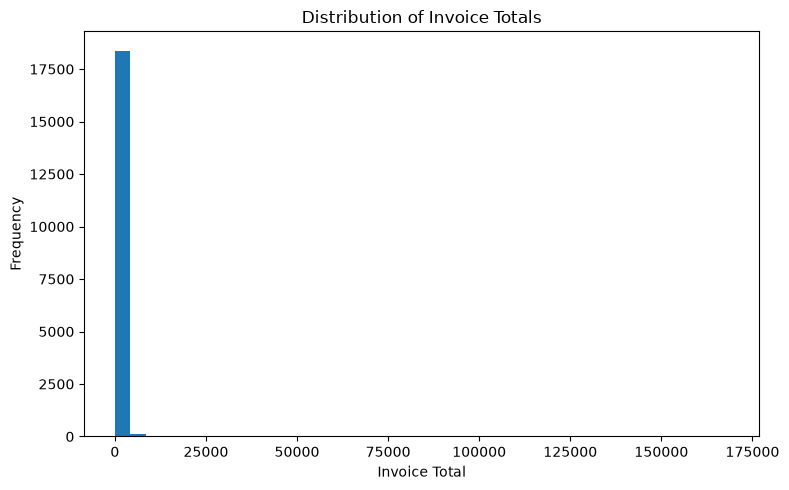

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(invoice_df["InvoiceTotal"], bins=40)

plt.title("Distribution of Invoice Totals")
plt.xlabel("Invoice Total")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [15]:
features = [
    "TotalQuantity",
    "UniqueProducts",
    "AverageUnitPrice",
    "Month",
    "DayOfWeek",
    "Hour"
]

X = invoice_df[features]

y = invoice_df["InvoiceTotal"]

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['TotalQuantity', 'UniqueProducts', 'AverageUnitPrice', 'Month', 'DayOfWeek', 'Hour']

X shape: (18532, 6)
y shape: (18532,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14825
Testing samples: 3707


## Model 1: Multiple Linear Regression

Multiple Linear Regression was selected as the first model. The model uses multiple invoice characteristics simultaneously to estimate the total value of an order.

In [17]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [18]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Multiple Linear Regression")
print("--------------------------")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Multiple Linear Regression
--------------------------
MAE: 157.06225441487848
MSE: 156583.8286650919
RMSE: 395.70674579174397
R²: 0.7280546142334745


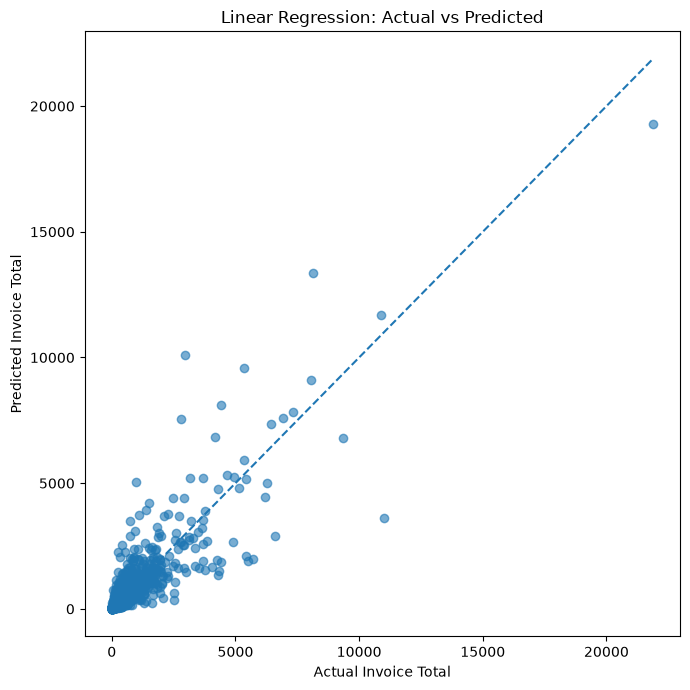

In [19]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.6
)

minimum = min(y_test.min(), linear_predictions.min())
maximum = max(y_test.max(), linear_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Invoice Total")
plt.ylabel("Predicted Invoice Total")

plt.tight_layout()
plt.show()

## Model 2: Ridge Regression

Ridge Regression was selected as the second model. Ridge applies L2 regularization, which reduces the magnitude of model coefficients and can help control overfitting. The numerical features were standardized before applying Ridge Regression.

In [20]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

print("Ridge Regression trained successfully.")

Ridge Regression trained successfully.


In [21]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("Ridge Regression")
print("----------------")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)

Ridge Regression
----------------
MAE: 157.05769349982097
MSE: 156571.52758759205
RMSE: 395.6912023126014
R²: 0.7280759780058037


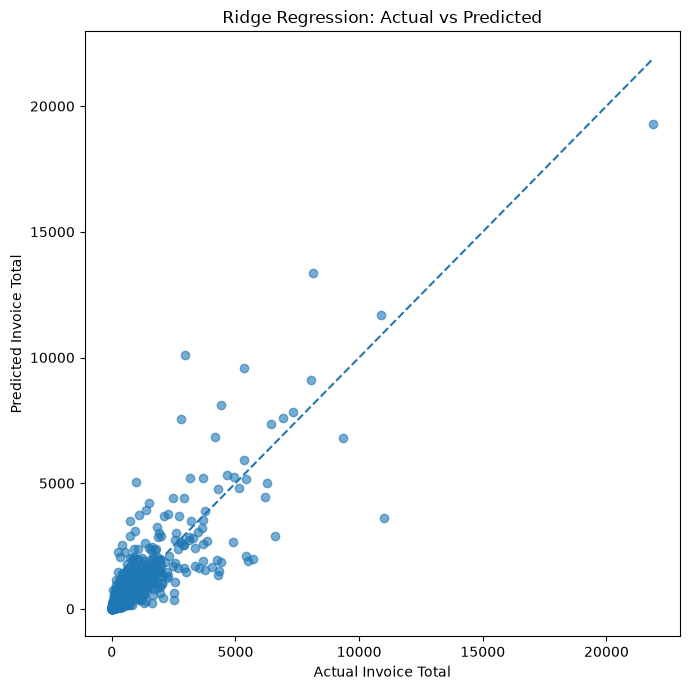

In [22]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    ridge_predictions,
    alpha=0.6
)

minimum = min(y_test.min(), ridge_predictions.min())
maximum = max(y_test.max(), ridge_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Ridge Regression: Actual vs Predicted")
plt.xlabel("Actual Invoice Total")
plt.ylabel("Predicted Invoice Total")

plt.tight_layout()
plt.show()

In [23]:
linear_cv = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Linear Regression Cross-Validation R² Scores:")
print(linear_cv)

print("\nAverage CV R²:")
print(linear_cv.mean())

Linear Regression Cross-Validation R² Scores:
[0.50408959 0.70600132 0.58192754 0.7049997  0.82732842]

Average CV R²:
0.6648693140340709


In [24]:
ridge_cv = cross_val_score(
    ridge_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Ridge Regression Cross-Validation R² Scores:")
print(ridge_cv)

print("\nAverage CV R²:")
print(ridge_cv.mean())

Ridge Regression Cross-Validation R² Scores:
[0.50422821 0.70603065 0.58193274 0.70499645 0.82729652]

Average CV R²:
0.6648969144941426


## Cross-Validation

Five-fold cross-validation was used to evaluate how well each regression model generalizes to unseen data. The dataset was divided into five sections. During each iteration, four sections were used for training and the remaining section was used for validation. The average R² score across the five folds provides a more reliable estimate of model performance than using only one train-test split.

In [25]:
results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Ridge Regression"
    ],

    "MAE": [
        linear_mae,
        ridge_mae
    ],

    "MSE": [
        linear_mse,
        ridge_mse
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse
    ],

    "R2": [
        linear_r2,
        ridge_r2
    ],

    "Mean CV R2": [
        linear_cv.mean(),
        ridge_cv.mean()
    ]
})

results.round(4)

,Model,MAE,MSE,RMSE,R2,Mean CV R2
0,Multiple Linear Regression,157.0623,156583.8287,395.7067,0.7281,0.6649
1,Ridge Regression,157.0577,156571.5276,395.6912,0.7281,0.6649


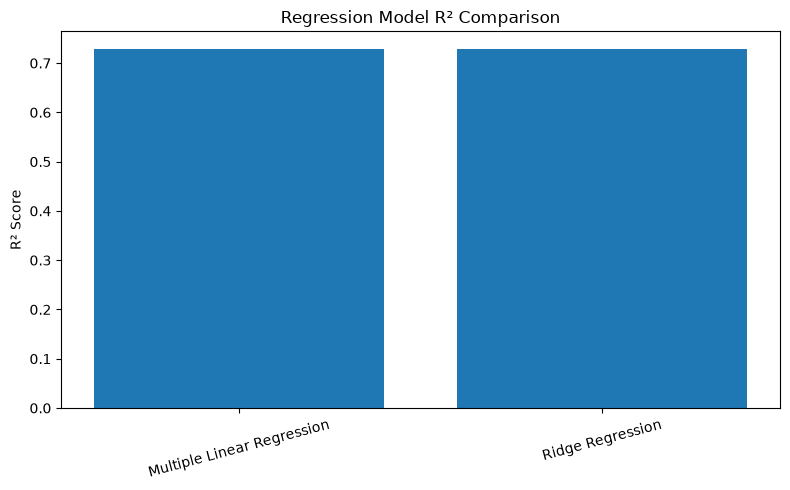

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.title("Regression Model R² Comparison")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

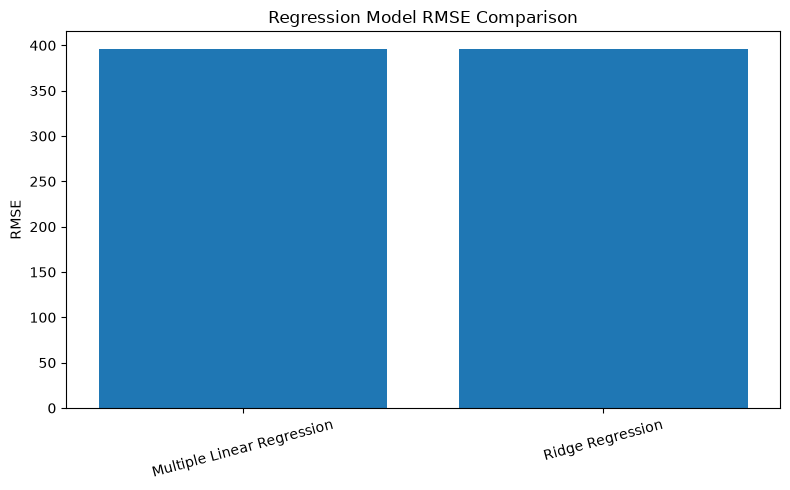

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("Regression Model RMSE Comparison")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

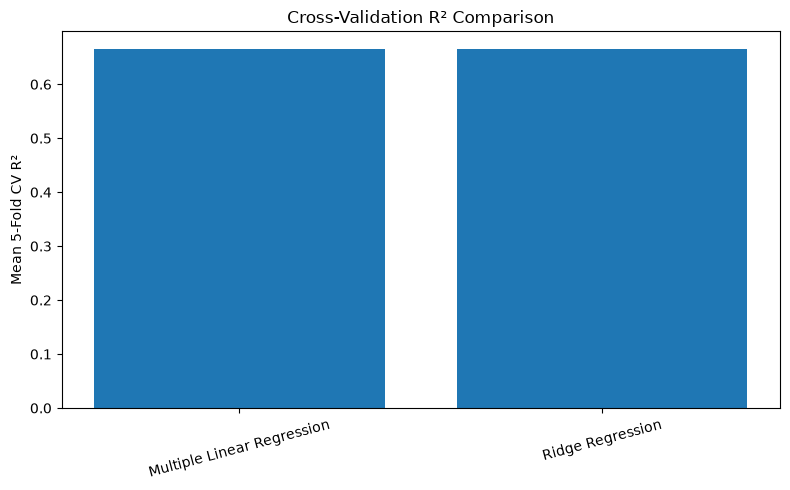

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Mean CV R2"]
)

plt.title("Cross-Validation R² Comparison")
plt.ylabel("Mean 5-Fold CV R²")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [29]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients["AbsoluteCoefficient"] = abs(
    coefficients["Coefficient"]
)

coefficients = coefficients.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,AbsoluteCoefficient
3,Month,3.547568,3.547568
2,AverageUnitPrice,1.642431,1.642431
0,TotalQuantity,1.570846,1.570846
1,UniqueProducts,1.284654,1.284654
5,Hour,0.734749,0.734749
4,DayOfWeek,-0.145325,0.145325


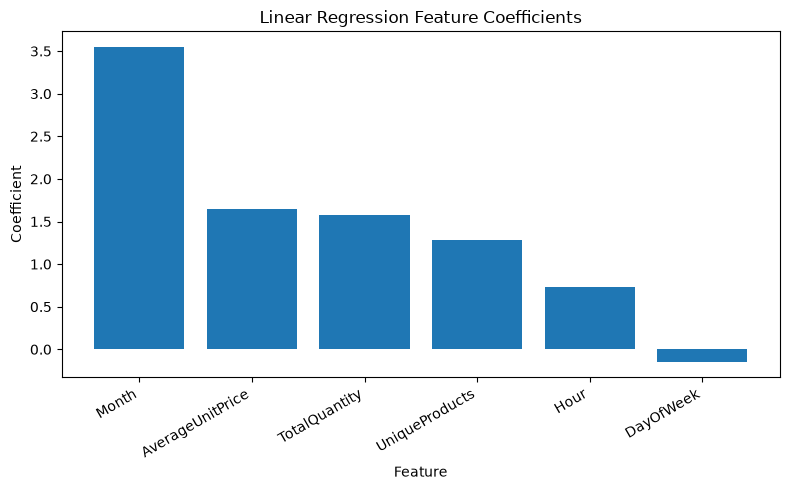

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

## Model Evaluation and Analysis

Two regression techniques were evaluated: Multiple Linear Regression and Ridge Regression. Both models used engineered invoice-level features including total quantity, number of unique products, average unit price, month, day of week, and transaction hour.

Model performance was evaluated using MAE, MSE, RMSE, R², and five-fold cross-validation. Lower MAE, MSE, and RMSE values indicate smaller prediction errors, while a higher R² value indicates that the model explains a larger portion of the variation in invoice totals.

Ridge Regression introduced regularization to reduce the influence of excessively large coefficients and potentially improve generalization. Cross-validation was used to determine whether the performance observed during the train-test split remained consistent across different portions of the dataset.

The feature engineering process transformed individual transaction records into meaningful invoice-level characteristics. This allowed the regression models to analyze how purchasing behavior, product variety, prices, and transaction timing relate to overall invoice value.